# Feature Quality Monitoring — Quickstart

This notebook walks you through Feast's data quality monitoring end-to-end:

1. Set up a feature store with a PostgreSQL offline store
2. Register features and trigger baseline computation
3. Compute metrics across multiple granularities
4. Read metrics via the Python SDK and REST API
5. Set up serving log monitoring
6. Use on-demand exploration for custom date ranges

**Prerequisites:** A running PostgreSQL instance and `feast[postgres]` installed.

## Step 1: Install Feast

In [1]:
!uv pip install -q 'feast[postgres]'

## Step 2: Configure the Feature Store

Create a minimal `feature_store.yaml` with a PostgreSQL offline store.

In [2]:
import os
import tempfile

REPO_DIR = tempfile.mkdtemp(prefix="feast_monitoring_demo_")
os.makedirs(REPO_DIR, exist_ok=True)
print(f"Working directory: {REPO_DIR}")

Working directory: /var/folders/cn/z7vz24yj25d8fjqdrs9jbsh00000gn/T/feast_monitoring_demo_kze7m3sk


In [ ]:
# Adjust these to match your PostgreSQL instance
PG_HOST = os.environ.get("FEAST_PG_HOST", "localhost")
PG_PORT = os.environ.get("FEAST_PG_PORT", "5432")
PG_DB = os.environ.get("FEAST_PG_DB", "feast")
PG_USER = os.environ.get("FEAST_PG_USER", "feast")
PG_PASS = os.environ.get("FEAST_PG_PASS", "feast")

PG_SSLMODE = os.environ.get("FEAST_PG_SSLMODE", "disable")

feature_store_yaml = f"""
project: monitoring_demo
registry:
    registry_type: sql
    path: postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}?sslmode={PG_SSLMODE}
provider: local
offline_store:
    type: postgres
    host: {PG_HOST}
    port: {PG_PORT}
    database: {PG_DB}
    user: {PG_USER}
    password: {PG_PASS}
    sslmode: {PG_SSLMODE}
online_store:
    type: sqlite
    path: {REPO_DIR}/online_store.db
entity_key_serialization_version: 3
"""

with open(os.path.join(REPO_DIR, "feature_store.yaml"), "w") as f:
    f.write(feature_store_yaml)

print("feature_store.yaml written.")

feature_store.yaml written.


## Step 3: Create Sample Data and Feature Definitions

In [4]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

N_ROWS = 5000
N_DAYS = 60

base_date = datetime(2025, 1, 1)
timestamps = [base_date + timedelta(days=int(d)) for d in np.random.randint(0, N_DAYS, N_ROWS)]

df = pd.DataFrame({
    "driver_id": np.random.randint(1000, 2000, N_ROWS),
    "event_timestamp": timestamps,
    "conv_rate": np.clip(np.random.normal(0.5, 0.2, N_ROWS), 0, 1),
    "acc_rate": np.clip(np.random.normal(0.7, 0.15, N_ROWS), 0, 1),
    "avg_daily_trips": np.random.poisson(20, N_ROWS).astype("int32"),
    "vehicle_type": np.random.choice(["sedan", "suv", "truck", "van", "compact"], N_ROWS),
    "created": timestamps,
})

print(f"Sample data: {len(df)} rows, {N_DAYS} days")
df.head()

Sample data: 5000 rows, 60 days


,driver_id,event_timestamp,conv_rate,acc_rate,avg_daily_trips,vehicle_type,created
0,1148,2025-02-08,0.348307,0.794390,14,compact,2025-02-08
1,1539,2025-02-21,0.305945,0.749046,25,van,2025-02-21
2,1487,2025-01-29,0.791641,0.784492,17,sedan,2025-01-29
3,1821,2025-01-15,0.267308,0.726226,17,sedan,2025-01-15
4,1437,2025-02-12,0.544618,0.729568,11,suv,2025-02-12


In [5]:
!uv pip install -q 'psycopg2'

In [6]:
# Load sample data into PostgreSQL'
from sqlalchemy import create_engine

engine = create_engine(f"postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}")
df.to_sql("driver_stats_source", engine, if_exists="replace", index=False)
print("Loaded sample data into PostgreSQL table 'driver_stats_source'.")

Loaded sample data into PostgreSQL table 'driver_stats_source'.


In [7]:
# Write feature definitions
definitions = '''
from datetime import timedelta
from feast import Entity, FeatureView, FeatureService, Field
from feast.types import Float32, Int32, String
from feast.infra.offline_stores.contrib.postgres_offline_store.postgres_source import (
    PostgreSQLSource,
)

driver = Entity(name="driver", join_keys=["driver_id"])

driver_stats_source = PostgreSQLSource(
    name="driver_stats_source",
    query="SELECT * FROM driver_stats_source",
    timestamp_field="event_timestamp",
    created_timestamp_column="created",
)

driver_stats_fv = FeatureView(
    name="driver_stats",
    entities=[driver],
    ttl=timedelta(days=365),
    schema=[
        Field(name="conv_rate", dtype=Float32),
        Field(name="acc_rate", dtype=Float32),
        Field(name="avg_daily_trips", dtype=Int32),
        Field(name="vehicle_type", dtype=String),
    ],
    source=driver_stats_source,
)

driver_service = FeatureService(
    name="driver_service",
    features=[driver_stats_fv],
)
'''

with open(os.path.join(REPO_DIR, "definitions.py"), "w") as f:
    f.write(definitions)

print("Feature definitions written.")

Feature definitions written.


## Step 4: Apply — Registers Features & Triggers Baseline

Running `feast apply` registers the feature definitions and automatically queues baseline metric computation.

In [8]:
import sys
from feast import FeatureStore

sys.path.insert(0, REPO_DIR)
from definitions import driver, driver_stats_source, driver_stats_fv, driver_service

store = FeatureStore(repo_path=REPO_DIR)
store.apply([driver, driver_stats_source, driver_stats_fv, driver_service])
print("Features registered. Baseline computation queued.")

/var/folders/cn/z7vz24yj25d8fjqdrs9jbsh00000gn/T/feast_monitoring_demo_kze7m3sk/definitions.py:9: DeprecationWarning: Entity value_type will be mandatory in the next release. Please specify a value_type for entity 'driver'.
  driver = Entity(name="driver", join_keys=["driver_id"])
The `path` of the `RegistryConfig` starts with a plain `postgresql` string. We are updating this to `postgresql+psycopg` to ensure that the `psycopg3` driver is used by `sqlalchemy`. If you want to use `psycopg2` pass `postgresql+psycopg2` explicitely to `path`. To silence this warning, pass `postgresql+psycopg` explicitely to `path`.


Features registered. Baseline computation queued.


## Step 5: Compute Batch Metrics

### 5a. Auto-compute (recommended for production)

Auto-compute detects the latest event timestamp and generates metrics for all 5 granularities: `daily`, `weekly`, `biweekly`, `monthly`, and `quarterly`.

In [9]:
from feast.monitoring.monitoring_service import MonitoringService

monitoring = MonitoringService(store)

result = monitoring.auto_compute(
    project="monitoring_demo",
)

print(f"Computed metrics for {result.get('computed_features', 'N/A')} features")
print(f"Granularities: {result.get('granularities', [])}")

Computed metrics for 20 features
Granularities: ['biweekly', 'daily', 'monthly', 'quarterly', 'weekly']


### 5b. Targeted compute (specific date range)

Compute `weekly` metrics for a specific window.

In [10]:
from datetime import date

result = monitoring.compute_metrics(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    start_date=date(2025, 1, 1),
    end_date=date(2025, 1, 7),
    granularity="weekly",
)

print(result)

{'status': 'completed', 'granularity': 'weekly', 'computed_features': 4, 'computed_feature_views': 1, 'computed_feature_services': 1, 'metric_dates': ['2025-01-01'], 'duration_ms': 43}


### 5c. Set a manual baseline

Use `set_baseline=True` to mark the computed metrics as the reference distribution.

In [11]:
result = monitoring.compute_metrics(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    start_date=date(2025, 1, 1),
    end_date=date(2025, 2, 28),
    granularity="daily",
    set_baseline=True,
)

print("Baseline set.")

Baseline set.


## Step 6: Read Metrics

### Per-feature metrics

In [12]:
metrics = monitoring.get_feature_metrics(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    feature_name="conv_rate",
    data_source_type="batch",
    granularity="daily",
)

for m in metrics[:3]:
    print(f"Date: {m['metric_date']}  Mean: {m['mean']:.4f}  Null rate: {m['null_rate']:.4f}  Rows: {m['row_count']}")

Date: 2025-01-01  Mean: 0.4989  Null rate: 0.0000  Rows: 4922
Date: 2025-02-28  Mean: 0.5201  Null rate: 0.0000  Rows: 104


### Categorical feature metrics

Categorical features (like `vehicle_type`) produce value-count histograms instead of numeric statistics.

In [23]:
cat_metrics = monitoring.get_feature_metrics(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    feature_name="vehicle_type",
    data_source_type="batch",
    granularity="daily",
)

for m in cat_metrics[:3]:
    print(f"Date: {m['metric_date']}  Type: {m['feature_type']}  "
          f"Rows: {m['row_count']}  Null rate: {m['null_rate']:.4f}")
    if m.get("histogram"):
        hist = m["histogram"]
        print(f"  Unique values: {hist['unique_count']}  Other count: {hist['other_count']}")
        for entry in hist["values"]:
            print(f"    {entry['value']}: {entry['count']}")

Date: 2025-01-01  Type: categorical  Rows: 4922  Null rate: 0.0000
  Unique values: 5  Other count: 0
    van: 1051
    suv: 1028
    sedan: 970
    truck: 954
    compact: 919
Date: 2025-02-28  Type: categorical  Rows: 104  Null rate: 0.0000
  Unique values: 5  Other count: 0
    compact: 26
    truck: 24
    sedan: 19
    van: 18
    suv: 17


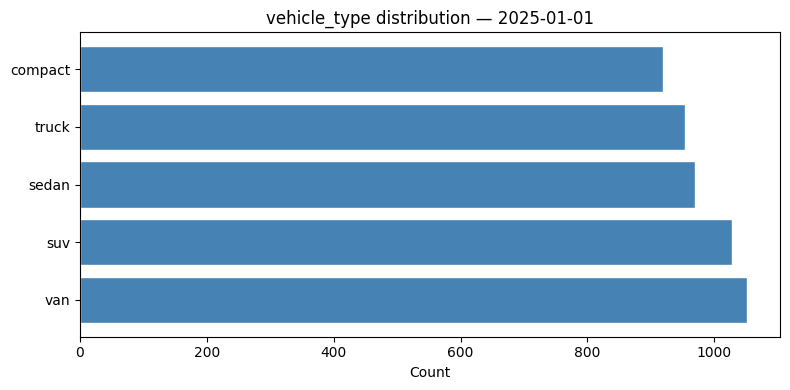

In [42]:
try:
    import matplotlib.pyplot as plt

    latest_cat = cat_metrics[0] if cat_metrics else None
    if latest_cat and latest_cat.get("histogram"):
        hist = latest_cat["histogram"]
        labels = [e["value"] for e in hist["values"]]
        counts = [e["count"] for e in hist["values"]]
        if hist["other_count"] > 0:
            labels.append("(other)")
            counts.append(hist["other_count"])

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.barh(labels, counts, color="steelblue", edgecolor="white")
        ax.set_title(f"vehicle_type distribution — {latest_cat['metric_date']}")
        ax.set_xlabel("Count")
        plt.tight_layout()
        plt.show()  # pragma: allowlist secret
    else:
        print("No categorical histogram data available.")
except ImportError:
    print("Install matplotlib to visualize: pip install matplotlib")

### Feature view aggregates

In [13]:
view_metrics = monitoring.get_feature_view_metrics(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    data_source_type="batch",
)

for m in view_metrics[:3]:
    print(f"Date: {m['metric_date']}  Total rows: {m['total_row_count']}  "
          f"Features w/ nulls: {m['features_with_nulls']}  Max null rate: {m.get('max_null_rate', 'N/A')}")

Date: 2024-12-01  Total rows: 5000  Features w/ nulls: 0  Max null rate: 0.0
Date: 2025-01-01  Total rows: 4922  Features w/ nulls: 0  Max null rate: 0.0
Date: 2025-01-01  Total rows: 576  Features w/ nulls: 0  Max null rate: 0.0


### Feature service aggregates

In [14]:
svc_metrics = monitoring.get_feature_service_metrics(
    project="monitoring_demo",
    feature_service_name="driver_service",
    data_source_type="batch",
)

for m in svc_metrics[:3]:
    print(f"Date: {m['metric_date']}  Total features: {m['total_features']}  "
          f"Avg null rate: {m.get('avg_null_rate', 'N/A')}")

Date: 2025-01-01  Total features: 4  Avg null rate: 0.0
Date: 2025-01-01  Total features: 4  Avg null rate: 0.0
Date: 2025-02-28  Total features: 4  Avg null rate: 0.0


### Baseline metrics

In [15]:
baseline = monitoring.get_baseline(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    feature_name="conv_rate",
    data_source_type="batch",
)

if baseline:
    print(f"Baseline mean: {baseline[0]['mean']:.4f}")
    print(f"Baseline stddev: {baseline[0]['stddev']:.4f}")
    print(f"Baseline null_rate: {baseline[0]['null_rate']:.4f}")
else:
    print("No baseline found.")

Baseline mean: 0.4989
Baseline stddev: 0.1975
Baseline null_rate: 0.0000


## Step 7: Visualize a Feature Distribution

Use the histogram stored in the metrics to plot a distribution.

In [18]:
!uv pip install -q 'matplotlib'

/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=12140) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


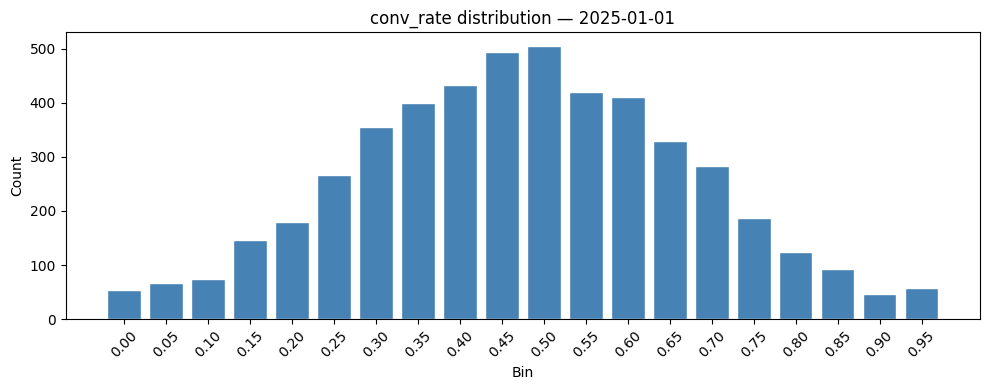

In [43]:
try:
    import matplotlib.pyplot as plt

    # Get the latest daily metric for conv_rate
    latest = metrics[0] if metrics else None
    if latest and latest.get("histogram"):
        hist = latest["histogram"]
        bins = hist["bins"]
        counts = hist["counts"]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(
            [f"{bins[i]:.2f}" for i in range(len(counts))],
            counts,
            color="steelblue",
            edgecolor="white",
        )
        ax.set_title(f"conv_rate distribution — {latest['metric_date']}")
        ax.set_xlabel("Bin")
        ax.set_ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()  # pragma: allowlist secret
    else:
        print("No histogram data available.")
except ImportError:
    print("Install matplotlib to visualize: pip install matplotlib")

## Step 8: Time-Series Trend

Plot how a metric (e.g., `mean`) evolves over time.

In [20]:
timeseries = monitoring.get_timeseries(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    feature_name="conv_rate",
    data_source_type="batch",
    granularity="daily",
    start_date=date(2025, 1, 1),
    end_date=date(2025, 3, 1),
)

if timeseries:
    dates = [t["metric_date"] for t in timeseries]
    means = [t["mean"] for t in timeseries]
    null_rates = [t["null_rate"] for t in timeseries]

    print(f"{len(timeseries)} data points from {dates[0]} to {dates[-1]}")
    for t in timeseries[:5]:
        print(f"  {t['metric_date']}: mean={t['mean']:.4f}, null_rate={t['null_rate']:.4f}")
    print("  ...")
else:
    print("No time-series data.")

2 data points from 2025-01-01 to 2025-02-28
  2025-01-01: mean=0.4989, null_rate=0.0000
  2025-02-28: mean=0.5201, null_rate=0.0000
  ...


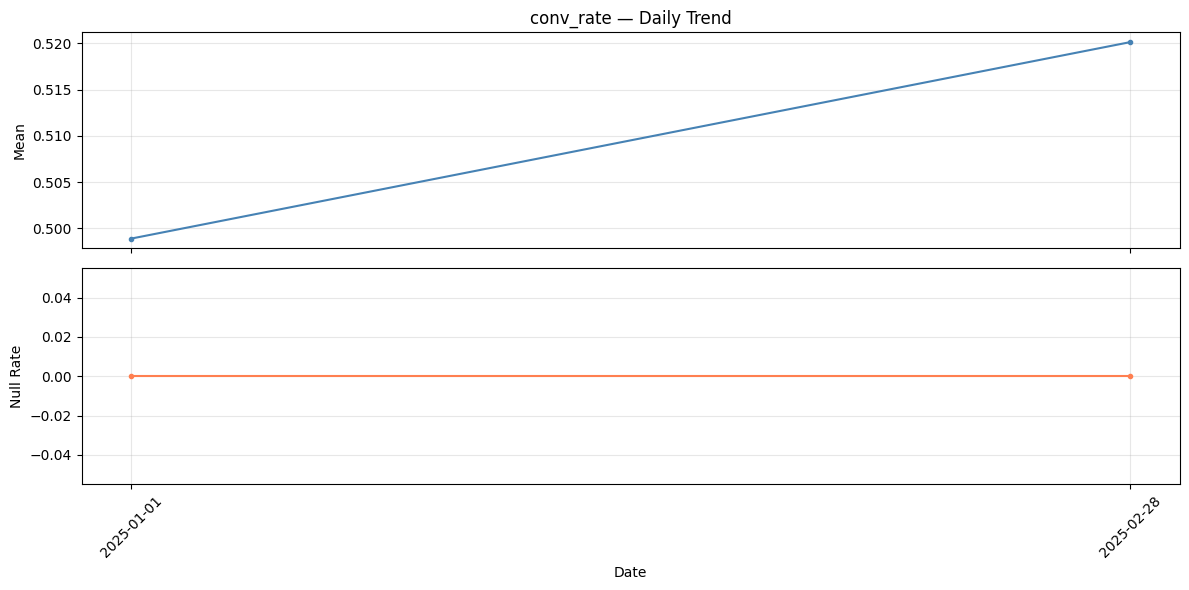

In [21]:
try:
    import matplotlib.pyplot as plt

    if timeseries:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

        ax1.plot(dates, means, marker=".", color="steelblue")
        ax1.set_ylabel("Mean")
        ax1.set_title("conv_rate — Daily Trend")
        ax1.grid(True, alpha=0.3)

        ax2.plot(dates, null_rates, marker=".", color="coral")
        ax2.set_ylabel("Null Rate")
        ax2.set_xlabel("Date")
        ax2.grid(True, alpha=0.3)

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()  # pragma: allowlist secret
except ImportError:
    print("Install matplotlib to visualize: pip install matplotlib")

## Step 9: On-Demand Exploration (Transient Compute)

Compute metrics for an arbitrary date range without storing them. Useful for ad-hoc investigation.

In [25]:
transient_result = monitoring.compute_transient(
    project="monitoring_demo",
    feature_view_name="driver_stats",
    feature_names=["conv_rate", "avg_daily_trips", "vehicle_type"],
    start_date=date(2025, 1, 10),
    end_date=date(2025, 1, 20),
)

for fm in transient_result.get("metrics", []):
    print(f"{fm['feature_name']} ({fm['feature_type']}):")
    print(f"  rows={fm['row_count']}  nulls={fm['null_count']}  null_rate={fm['null_rate']:.4f}")
    if fm["feature_type"] == "numeric":
        print(f"  mean={fm['mean']:.4f}  stddev={fm['stddev']:.4f}")
        print(f"  p50={fm['p50']:.4f}  p95={fm['p95']:.4f}  p99={fm['p99']:.4f}")
    elif fm["feature_type"] == "categorical" and fm.get("histogram"):
        hist = fm["histogram"]
        print(f"  unique_values={hist['unique_count']}")
        for entry in hist["values"]:
            print(f"    {entry['value']}: {entry['count']}")
    print()

conv_rate (numeric):
  rows=905  nulls=0  null_rate=0.0000
  mean=0.5041  stddev=0.1929
  p50=0.4964  p95=0.8221  p99=0.9757

avg_daily_trips (numeric):
  rows=905  nulls=0  null_rate=0.0000
  mean=20.1525  stddev=4.4410
  p50=20.0000  p95=27.0000  p99=31.9600

vehicle_type (categorical):
  rows=905  nulls=0  null_rate=0.0000
  unique_values=5
    van: 194
    sedan: 193
    suv: 186
    truck: 171
    compact: 161



## Step 10: REST API Usage

Once the Feast registry server is running, all monitoring endpoints are available via HTTP.

```bash
# Start the server
feast serve_registry
```

### Compute metrics via REST

In [41]:
# This cell is for reference — run it when the registry server is up.

import requests

BASE_URL = "http://localhost:6572/api/v1"

# Auto-compute all metrics
resp = requests.post(f"{BASE_URL}/monitoring/auto_compute", json={
    "project": "monitoring_demo",
})
print(resp.json())

# Read per-feature metrics
resp = requests.get(f"{BASE_URL}/monitoring/metrics/features", params={
    "project": "monitoring_demo",
    "feature_view_name": "driver_stats",
    "feature_name": "conv_rate",
    "granularity": "daily",
    "data_source_type": "batch",
})
print(resp.json())

# Read baseline
resp = requests.get(f"{BASE_URL}/monitoring/metrics/baseline", params={
    "project": "monitoring_demo",
    "feature_view_name": "driver_stats",
    "feature_name": "conv_rate",
    "data_source_type": "batch",
})
print(resp.json())

{'job_id': '077f59c5-c341-4fbb-9adc-b0111fc9228b', 'status': 'completed', 'computed_feature_views': 1, 'computed_features': 20, 'granularities': ['biweekly', 'daily', 'monthly', 'quarterly', 'weekly'], 'duration_ms': 98}
[{'project_id': 'monitoring_demo', 'feature_view_name': 'driver_stats', 'feature_name': 'conv_rate', 'metric_date': '2025-01-01', 'granularity': 'daily', 'data_source_type': 'batch', 'computed_at': '2026-04-21T13:41:42.687597+05:30', 'is_baseline': True, 'feature_type': 'numeric', 'row_count': 4922, 'null_count': 0, 'null_rate': 0.0, 'mean': 0.4988999058272324, 'stddev': 0.1975387054069251, 'min_val': 0.0, 'max_val': 1.0, 'p50': 0.4998365219303598, 'p75': 0.633892663793526, 'p90': 0.7521919750314627, 'p95': 0.825733080299169, 'p99': 0.9640086762359101, 'histogram': {'bins': [0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9

## Step 11: Monitoring Feature Serving Logs

If your feature service has logging enabled, you can compute metrics from actual production traffic.

### Define a feature service with logging

In [38]:
# Example feature service definition with logging
#
# from feast import FeatureService, LoggingConfig
# from feast.infra.offline_stores.contrib.postgres_offline_store.postgres_source import (
#     PostgreSQLLoggingDestination,
# )
#
# driver_service = FeatureService(
#     name="driver_service",
#     features=[driver_stats_fv],
#     logging_config=LoggingConfig(
#         destination=PostgreSQLLoggingDestination(table_name="feast_driver_logs"),
#         sample_rate=1.0,
#     ),
# )
print("See the code cell above for the logging config pattern.")
print("Once applied, log metrics can be computed with:")
print("  CLI:  feast monitor run --source-type log")
print("  API:  POST /monitoring/compute/log")
print("  SDK:  monitoring.compute_log_metrics(project, feature_service_name)")

See the code cell above for the logging config pattern.
Once applied, log metrics can be computed with:
  CLI:  feast monitor run --source-type log
  API:  POST /monitoring/compute/log
  SDK:  monitoring.compute_log_metrics(project, feature_service_name)


### Compute log metrics (SDK)

In [39]:
# Uncomment when you have a feature service with logging enabled
#
# result = monitoring.compute_log_metrics(
#     project="monitoring_demo",
#     feature_service_name="driver_service",
#     granularity="daily",
# )
# print(result)

# Or auto-compute all log metrics
# result = monitoring.auto_compute_log_metrics(project="monitoring_demo")
# print(result)

### Read log vs. batch metrics side-by-side

In [40]:
# Compare batch vs. log metrics for the same feature
#
# batch = monitoring.get_feature_metrics(
#     project="monitoring_demo",
#     feature_view_name="driver_stats",
#     feature_name="conv_rate",
#     data_source_type="batch",
#     granularity="daily",
# )
#
# log = monitoring.get_feature_metrics(
#     project="monitoring_demo",
#     feature_view_name="driver_stats",
#     feature_name="conv_rate",
#     data_source_type="log",
#     granularity="daily",
# )
#
# print("Batch metrics:")
# for m in batch[:3]:
#     print(f"  {m['metric_date']}: mean={m['mean']:.4f}")
#
# print("\nLog metrics:")
# for m in log[:3]:
#     print(f"  {m['metric_date']}: mean={m['mean']:.4f}")

print("Uncomment the cell above once log metrics have been computed.")

Uncomment the cell above once log metrics have been computed.


## Step 12: Scheduling in Production

### Cron (simplest)

```bash
# Compute all batch + log metrics daily at 2 AM
0 2 * * * cd /path/to/feast/repo && feast monitor run --source-type all >> /var/log/feast-monitor.log 2>&1
```

### Airflow

```python
from airflow.operators.bash import BashOperator

monitor_task = BashOperator(
    task_id="feast_monitor",
    bash_command="feast monitor run --source-type all",
    cwd="/path/to/feast/repo",
)
```

### Kubernetes CronJob

```yaml
apiVersion: batch/v1
kind: CronJob
metadata:
  name: feast-monitor
spec:
  schedule: "0 2 * * *"
  jobTemplate:
    spec:
      template:
        spec:
          containers:
          - name: feast-monitor
            image: feast-image:latest
            command: ["feast", "monitor", "run", "--source-type", "all"]
            volumeMounts:
            - name: feast-repo
              mountPath: /feast/repo
          restartPolicy: OnFailure
          volumes:
          - name: feast-repo
            configMap:
              name: feast-repo-config
```

## Summary

| Capability | CLI | REST API | SDK |
|-----------|-----|----------|-----|
| Auto-compute (all granularities) | `feast monitor run` | `POST /monitoring/auto_compute` | `monitoring.auto_compute_metrics()` |
| Targeted compute | `feast monitor run --feature-view X --granularity daily` | `POST /monitoring/compute` | `monitoring.compute_metrics()` |
| Set baseline | `feast monitor run --set-baseline` | `POST /monitoring/compute` (with `set_baseline: true`) | `monitoring.compute_metrics(set_baseline=True)` |
| Log metrics | `feast monitor run --source-type log` | `POST /monitoring/compute/log` | `monitoring.compute_log_metrics()` |
| On-demand exploration | — | `POST /monitoring/compute/transient` | `monitoring.compute_transient()` |
| Read metrics | — | `GET /monitoring/metrics/*` | `monitoring.get_feature_metrics()` etc. |
| Read baseline | — | `GET /monitoring/metrics/baseline` | `monitoring.get_baseline()` |
| Time-series | — | `GET /monitoring/metrics/timeseries` | `monitoring.get_timeseries()` |